# Second experiment

En este experimento vamos a intentar reproducir el fenómeno del doble descenso (doble descent) utilizando una red neuronal formada por 2 capas totalmente conectadas (ó densas), sobre la que modificaremos el número de unidades ("neuronas") de la primera capa, con el objetivo de aumentar la capacidad de la red neuronal. Además, trabajaremos con el dataset MNIST sin ruido agregado y con ruido agregado (15% y 10% sobre las etiquetas).

En primer lugar, importamos **keras** y el propio dataset MNIST que lo podemos encontrar dentro de los datasets que incorpora la propia biblioteca keras.

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

# Establecer la semilla que vamos a utilizar
np.random.seed(42)

from tensorflow import keras

#import keras
!pip install np_utils
from keras.utils import to_categorical
from keras.datasets import mnist
keras.utils.set_random_seed(42)

from keras import backend as K

# NÚMERO DE CLASES DE MNIST (10 CLASES)
num_classes = 10

# DIMENSIONES DE ENTRADA DE LAS IMÁGENES (28x28x1 (escala de grises))
img_rows, img_cols = 28, 28

# CARGAMOS LOS DATOS DE ENTRENAMIENTO Y TEST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

if K.image_data_format() == 'channels_first':
    x_train = x_train.reshape(x_train.shape[0], 1, img_rows, img_cols)
    x_test = x_test.reshape(x_test.shape[0], 1, img_rows, img_cols)
    input_shape = (1, img_rows, img_cols)
else:
    x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1)
    x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)
    input_shape = (img_rows, img_cols, 1)

# FORMATEAMOS Y NORMALIZAMOS LOS DATOS
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255
print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

# Transformamos los vectores de clases en matrices.
# Cada componente se convierte en un vector de ceros
# con un uno en la componente correspondiente a la
# clase a la que pertenece la imagen. Este paso es
# necesario para la clasificación multiclase en keras.
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for np_utils: filename=np_utils-0.6.0-py3-none-any.whl size=56437 sha256=8f4d92b2416b0b685581ed8bb64ba3b99dff354db2034cd98f9707c79425ec56
  Stored in directory: /root/.cache/pip/wheels/b6/c7/50/2307607f44366dd021209f660045f8d51cb976514d30be7cc7
Successfully built np_utils
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


A continuación, mostramos algunas de las imágenes que contiene el dataset (a modo intuitivo para conocer las imágenes con las que trabajamos).

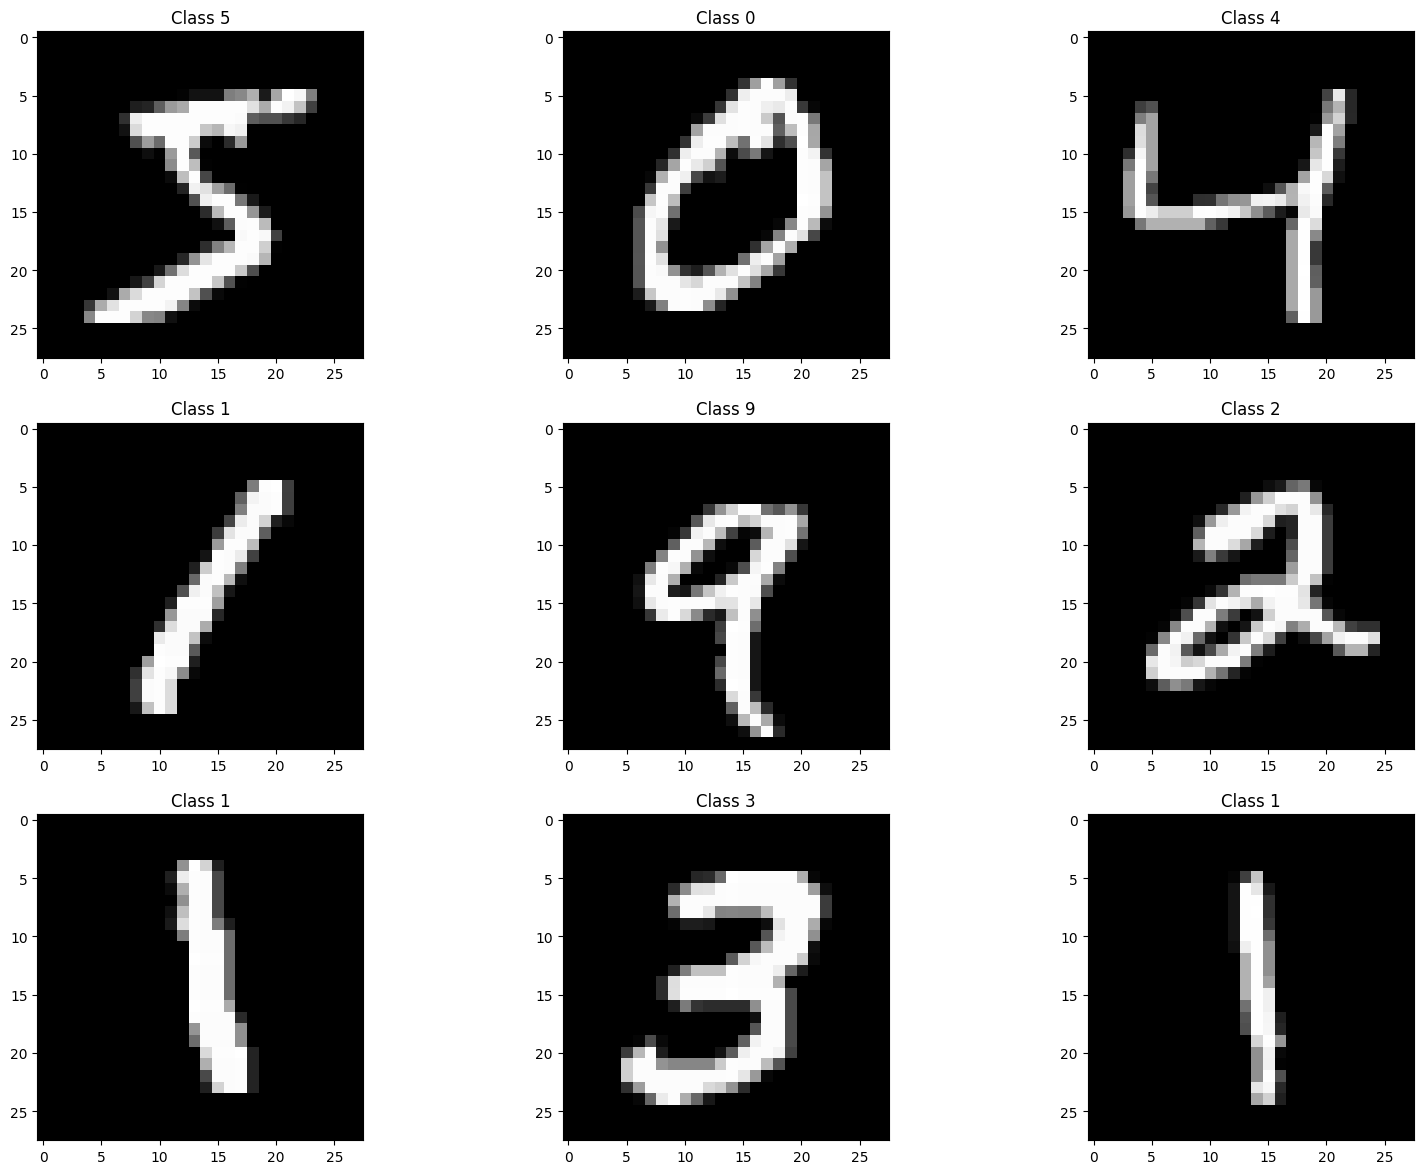

In [ ]:
#VISUALIZAMOS ALGUNAS DE LAS IMÁGENES DEL DATASET
number_images_per_row = 3
result = np.where(y_train == 1)
fig = plt.figure()
for i in range(number_images_per_row*number_images_per_row):
  label = 'Class {}'.format(result[1][i])
  plt.subplot(number_images_per_row,number_images_per_row,i+1).set_title(label)
  plt.imshow(x_train[i].squeeze(), cmap='gray',vmin=0,vmax=1)

fig.set_size_inches(np.array(fig.get_size_inches()) * number_images_per_row)

plt.show()

## Disminuimos el conjunto de datos

En este apartado nos encargamos de disminuir el conjunto de datos a utilizar (algo que, en general, no es lo más adecuado a la hora de entrenar, pues, según la sabiduría clásica, cuantos más datos mejor), de manera que sea más rápido entrenar.

Vamos a pasar de tener 60000 imágenes en entrenamiento y 10000 en test a 4000 imágenes en entrenamiento, 1000 en validación (propias del conjunto de entrenamiento. ¡OJO! Excluimos los ejemplos seleccionados del entrenamiento para que no vuelvan a aparecer en validación) y 1000 en validación.

In [ ]:
# Número de ejemplos que queremos mantener en cada conjunto
train_size = 4000
val_size = 1000
test_size = 1000

# Seleccionamos índices aleatorios para el conjunto de entrenamiento
random_training_indices = np.random.choice(x_train.shape[0], size=train_size, replace=False)

# Excluimos los índices ya seleccionados para el entrenamiento para la selección del conjunto de validación
remaining_indices = np.setdiff1d(np.arange(x_train.shape[0]), random_training_indices)

# Seleccionamos índices aleatorios para la validación del conjunto restante
random_validation_indices = np.random.choice(remaining_indices, size=val_size, replace=False)

# Seleccionamos índices aleatorios para el conjunto de test
random_test_indices = np.random.choice(x_test.shape[0], size=test_size, replace=False)

print('Tamaño conjunto de entrenamiento:', len(random_training_indices))
print('Tamaño conjunto de validación:', len(random_validation_indices))
print('Tamaño conjunto de test:', len(random_test_indices))

Tamaño conjunto de entrenamiento: 4000
Tamaño conjunto de validación: 1000
Tamaño conjunto de test: 1000


Almacenamos los ejemplos en sus respectivos conjuntos de datos.

In [ ]:
# Guardar los ejemplos de entrenamiento y sus etiquetas usando los índices seleccionados
x_train_reduced = x_train[random_training_indices]
y_train_reduced = y_train[random_training_indices]
x_valid_reduced = x_train[random_validation_indices]
y_valid_reduced = y_train[random_validation_indices]
x_test_reduced = x_test[random_test_indices]
y_test_reduced = y_test[random_test_indices]

print('x_train_reduced shape:', x_train_reduced.shape)
print('y_train_reduced shape:', y_train_reduced.shape)
print('x_valid_reduced shape:', x_valid_reduced.shape)
print('y_valid_reduced shape:', y_valid_reduced.shape)
print('x_test_reduced shape:', x_test_reduced.shape)
print('y_test_reduced shape:', y_test_reduced.shape)

x_train_reduced shape: (4000, 28, 28, 1)
y_train_reduced shape: (4000, 10)
x_valid_reduced shape: (1000, 28, 28, 1)
y_valid_reduced shape: (1000, 10)
x_test_reduced shape: (1000, 28, 28, 1)
y_test_reduced shape: (1000, 10)


Ahora, procedemos a verificar que tenemos, tanto en entrenamiento como en validación, ejemplos de todas las clases posibles y, en la medida de lo posible, que todas las clases estén representadas en la misma proporción, de manera que el entrenamiento a realizar sea lo más óptimo posible.

In [ ]:
# Convertimos las etiquetas en formato vector a formato escalar nuevamente (con el objetivo de contar el número de instancias de cada clase)
y_train_original = np.argmax(y_train_reduced, axis=1)

# Contamos los ejemplos por clase
unique, counts = np.unique(y_train_original, return_counts=True)

# Mostramos el número de ejemplos por clase
class_counts = dict(zip(unique, counts))
print(class_counts)

{0: 403, 1: 423, 2: 384, 3: 393, 4: 396, 5: 383, 6: 383, 7: 421, 8: 389, 9: 425}


Observamos como en el conjunto de entrenamiento tenemos prácticamente la misma proporción entre clases.

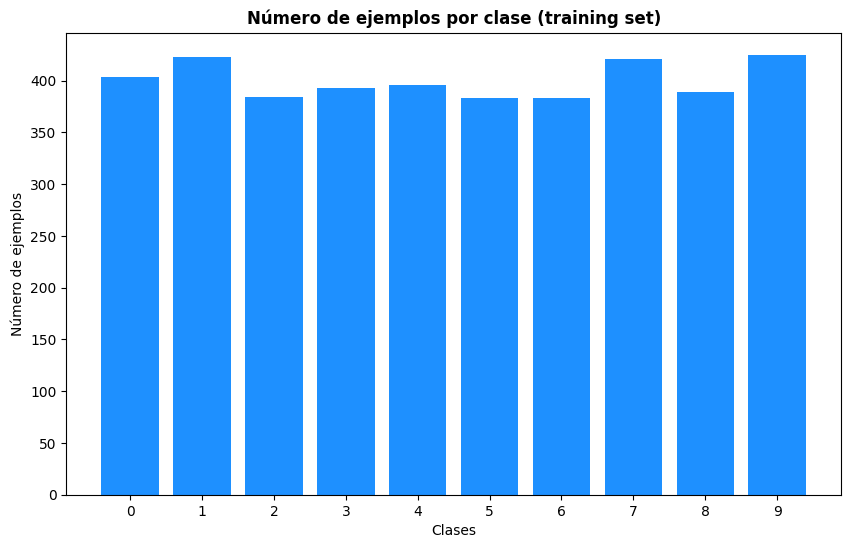

In [ ]:
# Extraemos las distintas clases y su respectivo número de instancias
classes = list(class_counts.keys())
num_examples = list(class_counts.values())

# Graficamos el número de ejemplos por clase
plt.figure(figsize=(10, 6))
plt.bar(classes, num_examples, color = 'dodgerblue')
plt.xlabel('Clases')
plt.ylabel('Número de ejemplos')
plt.title('Número de ejemplos por clase (training set)', fontweight = "bold")
plt.xticks(classes)
plt.show()

In [ ]:
y_valid_original = np.argmax(y_valid_reduced, axis=1)

unique, counts = np.unique(y_valid_original, return_counts=True)

class_counts = dict(zip(unique, counts))
print(class_counts)

{0: 96, 1: 127, 2: 92, 3: 128, 4: 105, 5: 79, 6: 83, 7: 110, 8: 83, 9: 97}


Observamos como en el conjunto de validación tenemos prácticamente la misma proporción entre clases.

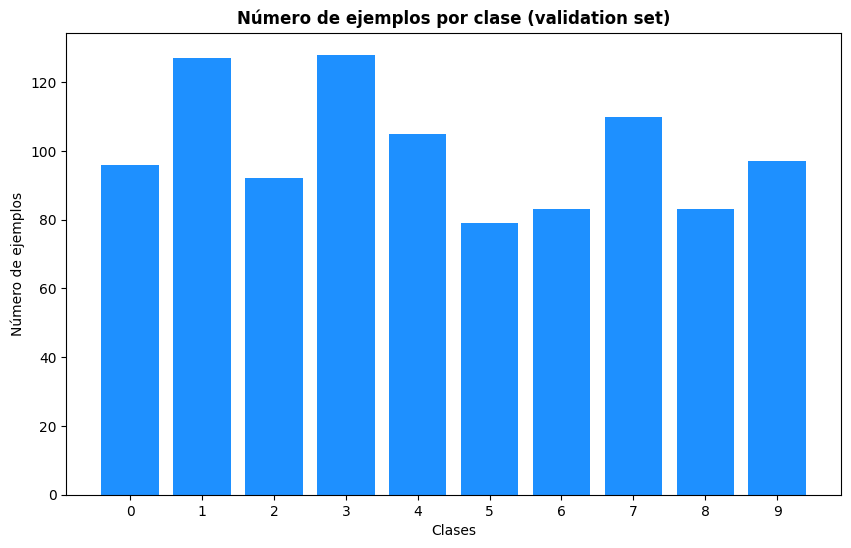

In [ ]:
classes = list(class_counts.keys())
num_examples = list(class_counts.values())

plt.figure(figsize=(10, 6))
plt.bar(classes, num_examples, color = 'dodgerblue')
plt.xlabel('Clases')
plt.ylabel('Número de ejemplos')
plt.title('Número de ejemplos por clase (validation set)', fontweight = "bold")
plt.xticks(classes)
plt.show()

## Model (2NN)

Nos encargamos ahora de definir el modelo neuronal a utilizar que, como se ha comentado anteriormente, será una red neuronal formada por 2 capas totalmente conectadas. De cara a aumentar la capacidad del modelo, dejaremos como parámetro el número de unidades de la primera capa totalmente conectada.

In [ ]:
from keras.models import Sequential
from keras.layers import  Dense, Input, Flatten

def create_model(size = 1):
  model = Sequential(name = "Model")
  model.add(Input(shape = (28, 28, 1), name = "Input"))
  model.add(Flatten(name = "Flatten")) # Flattening layer to convert output in 1D vector for dense layer (fully connected layers)
  model.add(Dense(units = size, activation='relu', name = "Dense_1"))
  model.add(Dense(units = num_classes, activation='softmax', name = "Dense_2"))

  return model

Mostramos un resumen de la arquitectura utilizada cuando usamos 1 y 100 unidades en la primera capa. Observamos como el número de parámetros de la red aumenta considerablemente de un caso a otro.

In [ ]:
model = create_model()
model.summary()

Model: "Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dense_1 (Dense)                      │ (None, 1)                   │             785 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dense_2 (Dense)                      │ (None, 10)                  │              20 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 805 (3.14 KB)

 Trainable params: 805 (3.14 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model = create_model(100)
model.summary()

Model: "Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dense_1 (Dense)                      │ (None, 100)                 │          78,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dense_2 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

Realmente, cabría esperar que el umbral de interpolación este cercano a cuando disponemos de 5 unidades en la primera capa, pues como podemos observar en el resumen siguiente, cuando tenemos 5 unidades tenemos un número de parámetros cercano a 4000, que son justamente el número de ejemplos de entrenamiento utilizados.

In [7]:
model = create_model(5)
model.summary()

Model: "Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dense_1 (Dense)                      │ (None, 5)                   │           3,925 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dense_2 (Dense)                      │ (None, 10)                  │              60 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,985 (15.57 KB)

 Trainable params: 3,985 (15.57 KB)

 Non-trainable params: 0 (0.00 B)

Finalmente, entrenamos y evaluamos la arquitectura anterior durante 1000 épocas, utilizando batches de 256 muestras y utilizando desde 1 a 50 unidades en la primera capa.

In [ ]:
import tensorflow as tf

batch_size = 256
num_epochs = 1000

num_units = np.arange(1, 51)

units_array = []
train_loss_array = []
train_accuracy_array = []
test_loss_array = []
test_accuracy_array = []

for units in num_units:
  model = create_model(size = units)

  model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

  print("\n ======> # of units in first dense layer: {} <======\n".format(units))
  hist = model.fit(x_train_reduced, y_train_reduced, batch_size = batch_size, epochs = num_epochs, verbose = 0, validation_data = (x_valid_reduced, y_valid_reduced), shuffle = True)

  train_loss, train_accuracy = model.evaluate(x_train_reduced, y_train_reduced)
  test_loss, test_accuracy = model.evaluate(x_test_reduced, y_test_reduced)

  # Almacenamos las estadísticas (número de unidades, error de entrenamiento, accuracy en entrenamiento, error en test, accuracy en test)
  units_array.append(units)
  train_loss_array.append(train_loss)
  train_accuracy_array.append(train_accuracy)
  test_loss_array.append(test_loss)
  test_accuracy_array.append(test_accuracy)


 ======> # of units in first dense layer: 1 <======

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3854 - loss: 1.5420
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3336 - loss: 1.7304

 ======> # of units in first dense layer: 2 <======

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6184 - loss: 0.9238
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5284 - loss: 1.4037

 ======> # of units in first dense layer: 3 <======

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8960 - loss: 0.3590
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7704 - loss: 1.1448

 ======> # of units in first dense layer: 4 <======

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9661 - loss: 0.1322
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8152 - loss: 0.9829

 ======> # of units in first dense layer: 5 <======

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9980 - loss: 0.0131
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8456 

Mostramos la gráfica obtenida relativa al error de entrenamiento y de test, donde podemos observar el fenómeno del doble descenso.

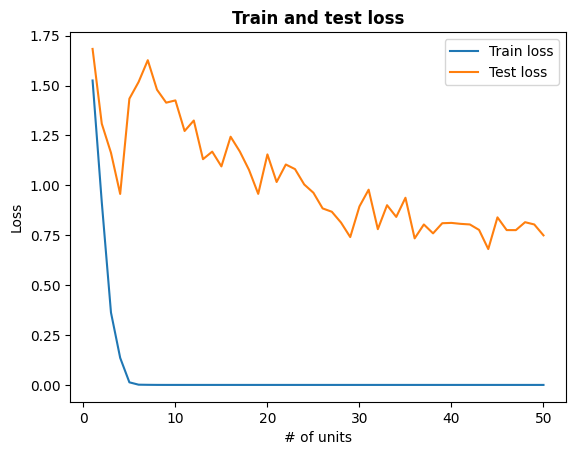

In [ ]:
# Graficamos el error de entrenamiento y test
x = np.arange(0, num_epochs, 1)
plt.title('Train and test loss', fontweight="bold")
plt.xlabel('# of units')
plt.ylabel('Loss')
plt.plot(units_array, train_loss_array, label='Train loss')
plt.plot(units_array, test_loss_array, label='Test loss')
plt.legend()
plt.show()

De cara a forzar aún más el doble descenso (observar claramente que la pérdida en test cuando usamos la arquitectura con más unidades es menor que la pérdida del error de test antes del pico que produce el doble descenso), decido entrenar y evaluar la arquitectura anterior utilizando hasta 100 unidades en la primera capa.

In [ ]:
import tensorflow as tf

batch_size = 256
num_epochs = 1000

# Crear un vector con elementos del 1 al 100
num_units = np.arange(1, 101)

units_array = []
train_loss_array = []
train_accuracy_array = []
test_loss_array = []
test_accuracy_array = []

for units in num_units:
  model = create_model(size = units)

  model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

  print("\n ======> # of units in first dense layer: {} <======\n".format(units))
  hist = model.fit(x_train_reduced, y_train_reduced, batch_size = batch_size, epochs = num_epochs, verbose = 0, validation_data = (x_valid_reduced, y_valid_reduced), shuffle = True)

  train_loss, train_accuracy = model.evaluate(x_train_reduced, y_train_reduced)
  test_loss, test_accuracy = model.evaluate(x_test_reduced, y_test_reduced)

  # save stats
  units_array.append(units)
  train_loss_array.append(train_loss)
  train_accuracy_array.append(train_accuracy)
  test_loss_array.append(test_loss)
  test_accuracy_array.append(test_accuracy)


 ======> # of units in first dense layer: 1 <======

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3854 - loss: 1.5420
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3336 - loss: 1.7304

 ======> # of units in first dense layer: 2 <======

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6184 - loss: 0.9238
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5284 - loss: 1.4037

 ======> # of units in first dense layer: 3 <======

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8960 - loss: 0.3590
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7704 - loss: 1.1448

 ======> # of units in first dense layer: 4 <======

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9659 - loss: 0.1322
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8152 - loss: 0.9828

 ======> # of units in first dense layer: 5 <======

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9980 - loss: 0.0131
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8456 

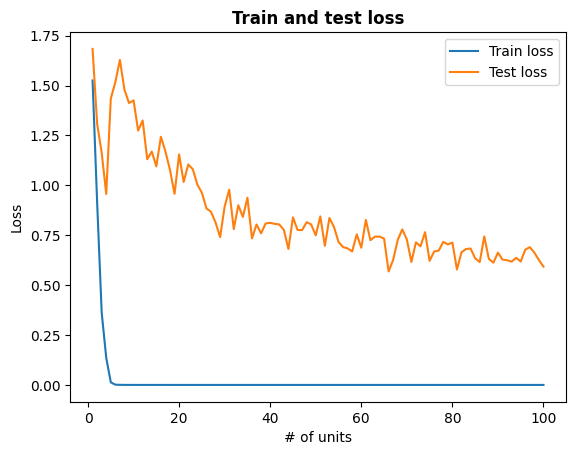

In [ ]:
x = np.arange(0, num_epochs, 1)
plt.title('Train and test loss', fontweight="bold")
plt.xlabel('# of units')
plt.ylabel('Loss')
plt.plot(units_array, train_loss_array, label='Train loss')
plt.plot(units_array, test_loss_array, label='Test loss')
plt.legend()
plt.show()

## Input noise (15%)

En este apartado decidí probar que le ocurre al double descent al añadir ruido sobre la propia entrada en lugar de sobre las etiquetas. Para ello, se agrega un 15% de ruido gaussiano, utilizando la función "**noise()**".

In [ ]:
num_classes = 10

img_rows, img_cols = 28, 28

(x_train, y_train), (x_test, y_test) = mnist.load_data()

if K.image_data_format() == 'channels_first':
    x_train = x_train.reshape(x_train.shape[0], 1, img_rows, img_cols)
    x_test = x_test.reshape(x_test.shape[0], 1, img_rows, img_cols)
    input_shape = (1, img_rows, img_cols)
else:
    x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1)
    x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)
    input_shape = (img_rows, img_cols, 1)

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255
print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


In [ ]:
def noise(array,noise_factor):
  """Adds random noise to each image in the supplied array."""
  noisy_array = array + noise_factor * np.random.normal(
      loc=0.0, scale=1.0, size=array.shape
  )

  return np.clip(noisy_array, 0.0, 1.0)

In [ ]:
noise_factor = 0.15
noisy_train_data = noise(x_train,noise_factor)
noisy_test_data = noise(x_test,noise_factor)

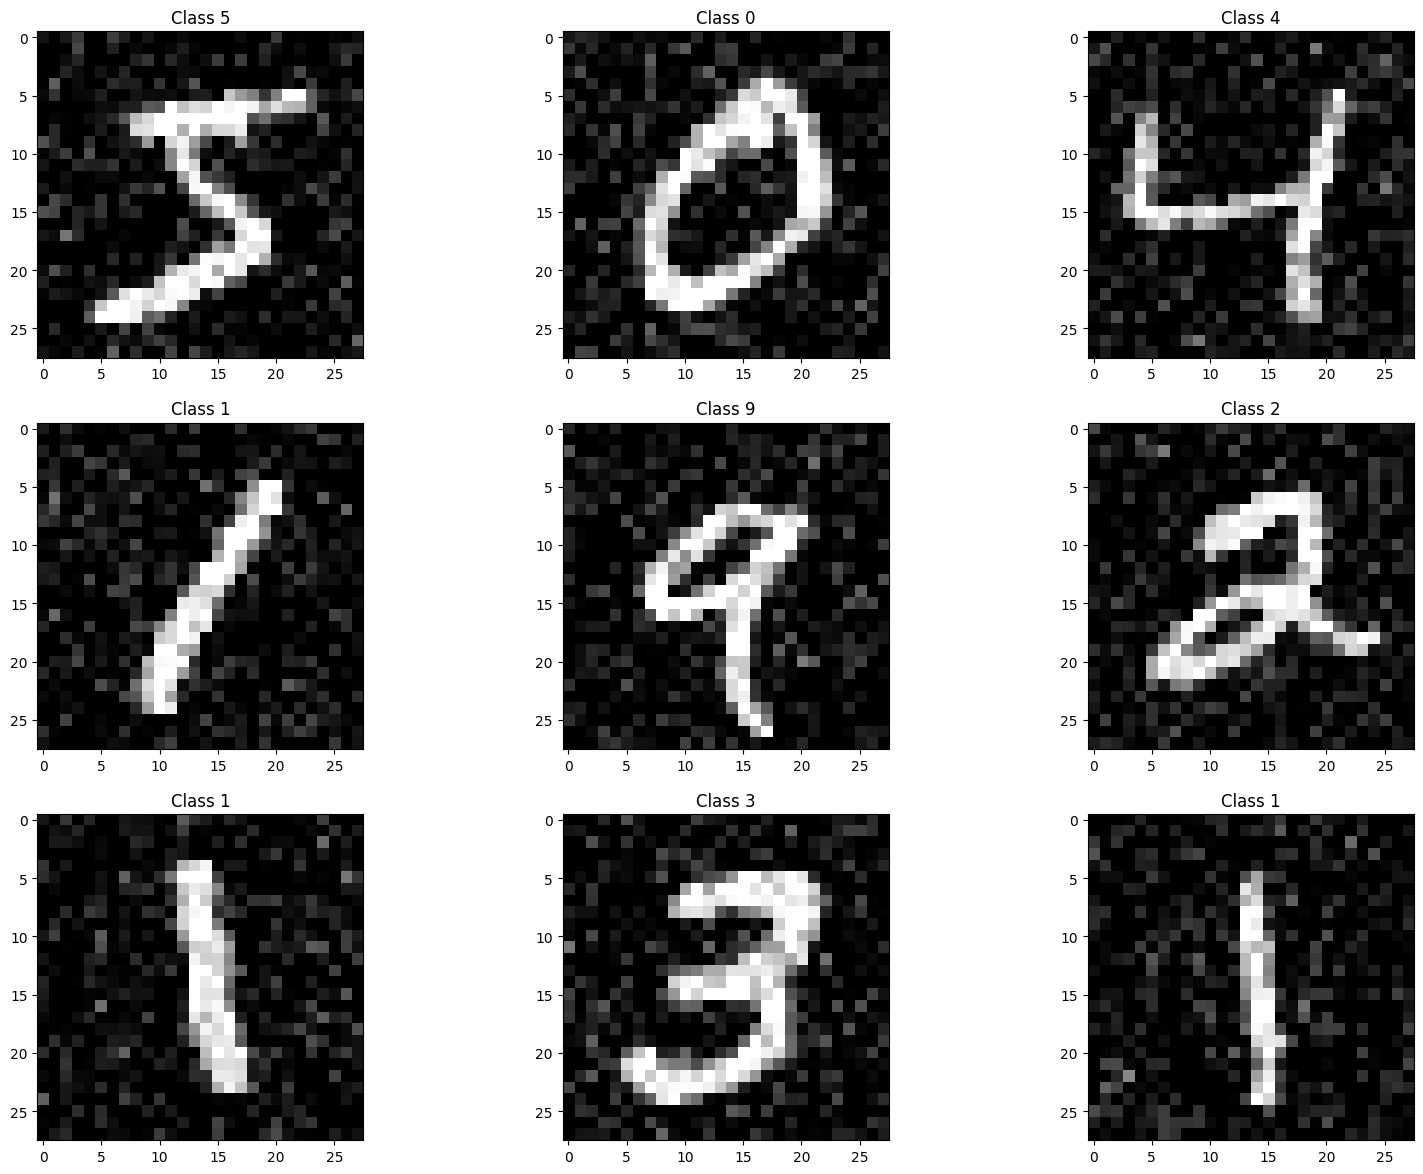

In [ ]:
#VISUALIZAMOS ALGUNAS DE LAS IMÁGENES DEL DATASET CON RUIDO AGREGADO
number_images_per_row = 3
result = np.where(y_train == 1)
fig = plt.figure()
for i in range(number_images_per_row*number_images_per_row):
  label = 'Class {}'.format(result[1][i])
  plt.subplot(number_images_per_row,number_images_per_row,i+1).set_title(label)
  plt.imshow(noisy_train_data[i].squeeze(), cmap='gray',vmin=0,vmax=1)

fig.set_size_inches(np.array(fig.get_size_inches()) * number_images_per_row)

plt.show()

In [ ]:
train_size = 4000
val_size = 1000
test_size = 1000

random_training_indices = np.random.choice(x_train.shape[0], size=train_size, replace=False)

remaining_indices = np.setdiff1d(np.arange(x_train.shape[0]), random_training_indices)

random_validation_indices = np.random.choice(remaining_indices, size=val_size, replace=False)

random_test_indices = np.random.choice(x_test.shape[0], size=test_size, replace=False)

print('Tamaño conjunto de entrenamiento:', len(random_training_indices))
print('Tamaño conjunto de validación:', len(random_validation_indices))
print('Tamaño conjunto de test:', len(random_test_indices))

Tamaño conjunto de entrenamiento: 4000
Tamaño conjunto de validación: 1000
Tamaño conjunto de test: 1000


In [ ]:
x_train_reduced = noisy_train_data[random_training_indices]
y_train_reduced = y_train[random_training_indices]
x_valid_reduced = noisy_train_data[random_validation_indices]
y_valid_reduced = y_train[random_validation_indices]
x_test_reduced = noisy_test_data[random_test_indices]
y_test_reduced = y_test[random_test_indices]

print('x_train_reduced shape:', x_train_reduced.shape)
print('y_train_reduced shape:', y_train_reduced.shape)
print('x_valid_reduced shape:', x_valid_reduced.shape)
print('y_valid_reduced shape:', y_valid_reduced.shape)
print('x_test_reduced shape:', x_test_reduced.shape)
print('y_test_reduced shape:', y_test_reduced.shape)

x_train_reduced shape: (4000, 28, 28, 1)
y_train_reduced shape: (4000, 10)
x_valid_reduced shape: (1000, 28, 28, 1)
y_valid_reduced shape: (1000, 10)
x_test_reduced shape: (1000, 28, 28, 1)
y_test_reduced shape: (1000, 10)


## Model (2NN)

In [ ]:
from keras.models import Sequential
from keras.layers import  Dense, Input, Flatten

def create_model(size = 1):
  model = Sequential(name = "Model")
  model.add(Input(shape = (28, 28, 1), name = "Input"))
  model.add(Flatten(name = "Flatten"))
  model.add(Dense(units = size, activation='relu', name = "Dense_1"))
  model.add(Dense(units = num_classes, activation='softmax', name = "Dense_2"))

  return model

In [ ]:
model = create_model()
model.summary()

Model: "Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dense_1 (Dense)                      │ (None, 1)                   │             785 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dense_2 (Dense)                      │ (None, 10)                  │              20 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 805 (3.14 KB)

 Trainable params: 805 (3.14 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf

batch_size = 256
num_epochs = 1000

num_units = np.arange(1, 51)

units_array = []
train_loss_array = []
train_accuracy_array = []
test_loss_array = []
test_accuracy_array = []

for units in num_units:
  model = create_model(size = units)

  model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

  print("\n ======> # of units in first dense layer: {} <======\n".format(units))
  hist = model.fit(x_train_reduced, y_train_reduced, batch_size = batch_size, epochs = num_epochs, verbose = 0, validation_data = (x_valid_reduced, y_valid_reduced), shuffle = True)

  train_loss, train_accuracy = model.evaluate(x_train_reduced, y_train_reduced)
  test_loss, test_accuracy = model.evaluate(x_test_reduced, y_test_reduced)

  units_array.append(units)
  train_loss_array.append(train_loss)
  train_accuracy_array.append(train_accuracy)
  test_loss_array.append(test_loss)
  test_accuracy_array.append(test_accuracy)


 ======> # of units in first dense layer: 1 <======

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1117 - loss: 2.2999
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1002 - loss: 2.3060

 ======> # of units in first dense layer: 2 <======

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3427 - loss: 1.5253
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2292 - loss: 2.1497

 ======> # of units in first dense layer: 3 <======

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9113 - loss: 0.3007
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6748 - loss: 1.7331

 ======> # of units in first dense layer: 4 <======

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9997 - loss: 0.0226
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7047 - loss: 2.8378

 ======> # of units in first dense layer: 5 <======

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9997 - loss: 8.3542e-04
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7

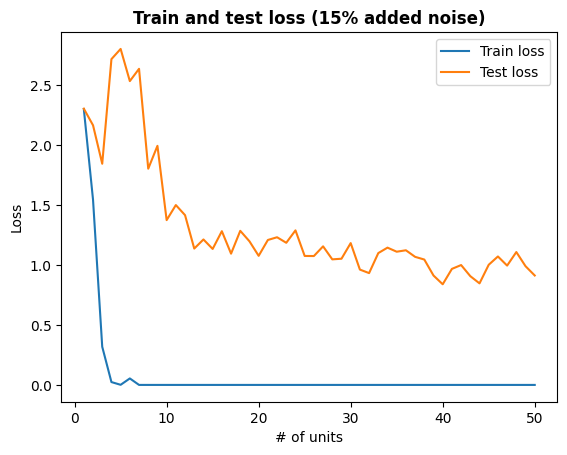

In [ ]:
x = np.arange(0, num_epochs, 1)
plt.title('Train and test loss (15% added noise)', fontweight="bold")
plt.xlabel('# of units')
plt.ylabel('Loss')
plt.plot(units_array, train_loss_array, label='Train loss')
plt.plot(units_array, test_loss_array, label='Test loss')
plt.legend()
plt.show()

Cabe destacar que el error de test es mayor que al caso sin ruido pero que el pico del error se encuentra cercano al del caso sin ruido (cercano a 5 unidades en la primera capa). Es decir, introducir ruido en la entrada parece NO desplazar el umbral de interpolación hacia la derecha.

## Noisy targets (15%)

En este apartado, vamos a replicar los experimentos realizados en el apartado anterior con la salvedad de que introducimos un cierto % de ruido a las etiquetas del conjunto de datos utilizado, con el objetivo de obtnener un pico más "pronunciado" relativo al doble descenso, tal y como se comenta en los diferentes papers.

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

np.random.seed(42)

from tensorflow import keras

!pip install np_utils
from keras.utils import to_categorical
from keras.datasets import mnist
keras.utils.set_random_seed(42)

from keras import backend as K

num_classes = 10

img_rows, img_cols = 28, 28

(x_train, y_train), (x_test, y_test) = mnist.load_data()

if K.image_data_format() == 'channels_first':
    x_train = x_train.reshape(x_train.shape[0], 1, img_rows, img_cols)
    x_test = x_test.reshape(x_test.shape[0], 1, img_rows, img_cols)
    input_shape = (1, img_rows, img_cols)
else:
    x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1)
    x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)
    input_shape = (img_rows, img_cols, 1)

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255
print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


In [ ]:
train_size = 4000
val_size = 1000
test_size = 1000

random_training_indices = np.random.choice(x_train.shape[0], size=train_size, replace=False)

remaining_indices = np.setdiff1d(np.arange(x_train.shape[0]), random_training_indices)

random_validation_indices = np.random.choice(remaining_indices, size=val_size, replace=False)

random_test_indices = np.random.choice(x_test.shape[0], size=test_size, replace=False)

print('Tamaño conjunto de entrenamiento:', len(random_training_indices))
print('Tamaño conjunto de validación:', len(random_validation_indices))
print('Tamaño conjunto de test:', len(random_test_indices))

Tamaño conjunto de entrenamiento: 4000
Tamaño conjunto de validación: 1000
Tamaño conjunto de test: 1000


In [ ]:
x_train_reduced = x_train[random_training_indices]
y_train_reduced = y_train[random_training_indices]
y_train_reduced_original = y_train[random_training_indices]
x_valid_reduced = x_train[random_validation_indices]
y_valid_reduced = y_train[random_validation_indices]
x_test_reduced = x_test[random_test_indices]
y_test_reduced = y_test[random_test_indices]

print('x_train_reduced shape:', x_train_reduced.shape)
print('y_train_reduced shape:', y_train_reduced.shape)
print('x_valid_reduced shape:', x_valid_reduced.shape)
print('y_valid_reduced shape:', y_valid_reduced.shape)
print('x_test_reduced shape:', x_test_reduced.shape)
print('y_test_reduced shape:', y_test_reduced.shape)

x_train_reduced shape: (4000, 28, 28, 1)
y_train_reduced shape: (4000,)
x_valid_reduced shape: (1000, 28, 28, 1)
y_valid_reduced shape: (1000,)
x_test_reduced shape: (1000, 28, 28, 1)
y_test_reduced shape: (1000,)


Aquí es donde agregamos un 15% de ruido a las etiquetas (cambiamos el valor real de la clase del ejemplo por cualquier otro).

In [ ]:
# Calculamos el número de etiquetas a cambiar (15% de y_train_reduced)
noise = 0.15
num_labels_to_change = int(noise * len(y_train_reduced))

# Seleccionamos aleatoriamente los índices a cambiar
indices_to_change = np.random.choice(len(y_train_reduced), num_labels_to_change, replace=False)

# Cambiamos las etiquetas en los índices seleccionados
unique_classes = np.unique(y_train_reduced)

for i in indices_to_change:
    current_label = y_train_reduced[i]
    # Seleccionamos una etiqueta diferente a la actual
    new_label = np.random.choice(unique_classes[unique_classes != current_label])
    y_train_reduced[i] = new_label

In [ ]:
y_train_reduced = keras.utils.to_categorical(y_train_reduced, num_classes)
y_train_reduced_original = keras.utils.to_categorical(y_train_reduced_original, num_classes)
y_valid_reduced = keras.utils.to_categorical(y_valid_reduced, num_classes)
y_test_reduced = keras.utils.to_categorical(y_test_reduced, num_classes)

In [ ]:
y_train_original = np.argmax(y_train_reduced, axis=1)

unique, counts = np.unique(y_train_original, return_counts=True)

class_counts = dict(zip(unique, counts))
print(class_counts)

{0: 418, 1: 421, 2: 397, 3: 375, 4: 396, 5: 394, 6: 381, 7: 430, 8: 374, 9: 414}


Observamos como se mantiene la proporción de ejemplos entre las diferentes clases del conjunto de entrenamiento (aunque hayamos modificado un 15% de los valores).

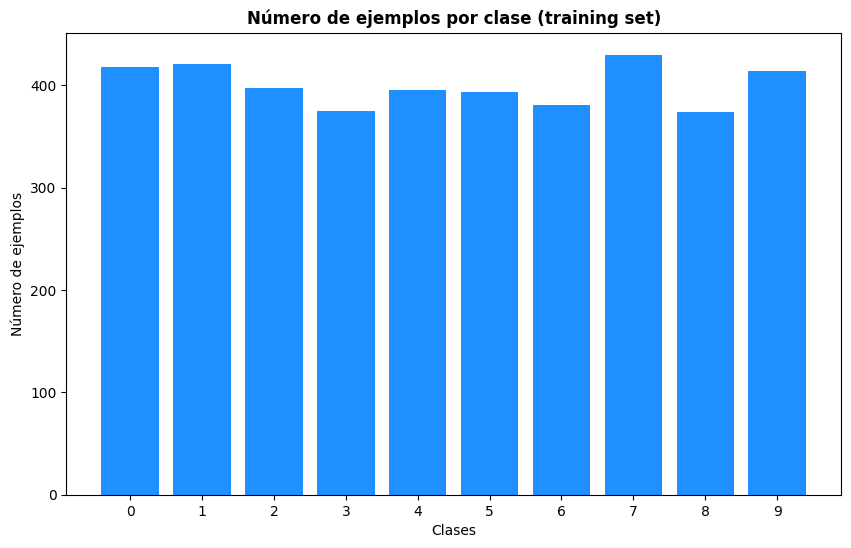

In [ ]:
classes = list(class_counts.keys())
num_examples = list(class_counts.values())

plt.figure(figsize=(10, 6))
plt.bar(classes, num_examples, color = 'dodgerblue')
plt.xlabel('Clases')
plt.ylabel('Número de ejemplos')
plt.title('Número de ejemplos por clase (training set)', fontweight = "bold")
plt.xticks(classes)
plt.show()

In [ ]:
# Convertimos las etiquetas en formato vector a formato escalar nuevamente (con el objetivo de contar el número de instancias de cada clase)
y_train_reduced_original_scalar = np.argmax(y_train_reduced_original, axis=1)

# Comparar etiquetas originales con las modificadas para identificar cuáles cambiaron
modificaciones = y_train_original != y_train_reduced_original_scalar

# Obtener los índices donde las etiquetas fueron cambiadas
indices_modificados = np.where(modificaciones)[0]

# Mostramos los índices de los ejemplos modificados
print(f"Los índices modificados son: \n {indices_modificados}")

# Obtenemos el número de ejemplos modificados
num_modificaciones = len(indices_modificados)
print(f"\nEl número de etiquetas modificadas es: {num_modificaciones}")

# Obtenemos el % de ejemplos modificados
percentage = (len(indices_modificados)/len(y_train_original))*100
print(f"\nEl porcentaje de etiquetas modificadas es: {percentage}%")

Los índices modificados son: 
 [   1   22   28   29   34   35   39   43   45   47   56   67   73   83
   88   91  108  120  121  130  155  161  164  169  182  190  203  204
  220  242  250  256  257  265  268  270  271  272  285  291  311  316
  317  320  322  325  329  349  351  354  369  371  372  378  383  384
  386  390  391  401  405  408  413  416  422  423  424  436  440  444
  448  451  471  475  479  483  493  495  497  513  516  523  525  526
  528  533  536  546  551  554  568  570  574  575  580  581  587  589
  592  594  610  616  639  644  664  668  671  690  694  700  705  707
  713  714  715  724  727  733  739  741  745  749  754  769  771  775
  778  780  782  787  791  794  796  798  806  809  820  829  831  832
  834  847  860  870  871  886  890  894  898  904  914  922  934  943
  952  953  964  967  980  996 1004 1005 1016 1021 1032 1042 1054 1056
 1059 1077 1099 1102 1118 1128 1129 1136 1142 1151 1153 1160 1165 1172
 1180 1183 1194 1195 1196 1208 1209 1210 1215 

## Model (2NN)

In [ ]:
from keras.models import Sequential
from keras.layers import  Dense, Input, Flatten

def create_model(size = 1):
  model = Sequential(name = "Model")
  model.add(Input(shape = (28, 28, 1), name = "Input"))
  model.add(Flatten(name = "Flatten"))
  model.add(Dense(units = size, activation='relu', name = "Dense_1"))
  model.add(Dense(units = num_classes, activation='softmax', name = "Dense_2"))

  return model

In [ ]:
model = create_model()
model.summary()

Model: "Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dense_1 (Dense)                      │ (None, 1)                   │             785 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dense_2 (Dense)                      │ (None, 10)                  │              20 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 805 (3.14 KB)

 Trainable params: 805 (3.14 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf

batch_size = 256
num_epochs = 1000

num_units = np.arange(1, 51)

units_array = []
train_loss_array = []
train_accuracy_array = []
test_loss_array = []
test_accuracy_array = []

for units in num_units:
  model = create_model(size = units)

  model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

  print("\n ======> # of units in first dense layer: {} <======\n".format(units))
  hist = model.fit(x_train_reduced, y_train_reduced, batch_size = batch_size, epochs = num_epochs, verbose = 0, validation_data = (x_valid_reduced, y_valid_reduced), shuffle = True)

  train_loss, train_accuracy = model.evaluate(x_train_reduced, y_train_reduced)
  test_loss, test_accuracy = model.evaluate(x_test_reduced, y_test_reduced)

  units_array.append(units)
  train_loss_array.append(train_loss)
  train_accuracy_array.append(train_accuracy)
  test_loss_array.append(test_loss)
  test_accuracy_array.append(test_accuracy)


 ======> # of units in first dense layer: 1 <======

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2631 - loss: 1.8833
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2703 - loss: 1.8471

 ======> # of units in first dense layer: 2 <======

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4988 - loss: 1.4736
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4805 - loss: 1.4629

 ======> # of units in first dense layer: 3 <======

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7097 - loss: 1.1237
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6674 - loss: 1.0641

 ======> # of units in first dense layer: 4 <======

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7467 - loss: 0.9539
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7011 - loss: 1.0301

 ======> # of units in first dense layer: 5 <======

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8083 - loss: 0.7471
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7261 

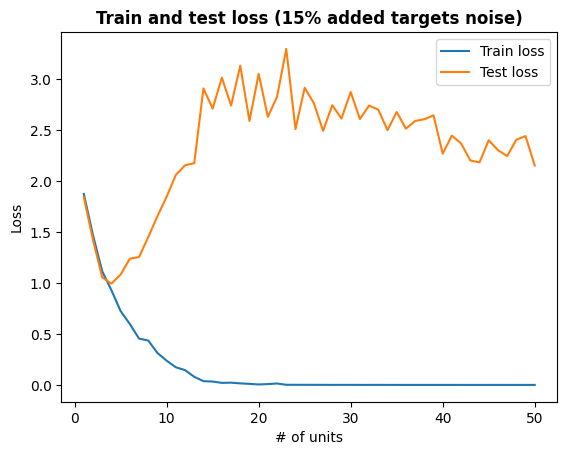

In [ ]:
x = np.arange(0, num_epochs, 1)
plt.title('Train and test loss (15% added targets noise)', fontweight="bold")
plt.xlabel('# of units')
plt.ylabel('Loss')
plt.plot(units_array, train_loss_array, label='Train loss')
plt.plot(units_array, test_loss_array, label='Test loss')
plt.legend()
plt.show()

  Podemos observar como el pico es más "pronunciado" que en el error de test sin ruido y, además, este pico está ligeramente desplazado hacia la derecha, como cabría esperar.

## Noisy targets (10% up to 100 units)

Mismo experimento que en el caso anterior pero reducimos el ruido al 10% y aumentamos el número de unidades de la primera capa hasta 100 unidades.

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

np.random.seed(42)

from tensorflow import keras

!pip install np_utils
from keras.utils import to_categorical
from keras.datasets import mnist
keras.utils.set_random_seed(42)

from keras import backend as K

num_classes = 10

img_rows, img_cols = 28, 28

(x_train, y_train), (x_test, y_test) = mnist.load_data()

if K.image_data_format() == 'channels_first':
    x_train = x_train.reshape(x_train.shape[0], 1, img_rows, img_cols)
    x_test = x_test.reshape(x_test.shape[0], 1, img_rows, img_cols)
    input_shape = (1, img_rows, img_cols)
else:
    x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1)
    x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)
    input_shape = (img_rows, img_cols, 1)

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255
print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


In [ ]:
train_size = 4000
val_size = 1000
test_size = 1000

random_training_indices = np.random.choice(x_train.shape[0], size=train_size, replace=False)

remaining_indices = np.setdiff1d(np.arange(x_train.shape[0]), random_training_indices)

random_validation_indices = np.random.choice(remaining_indices, size=val_size, replace=False)

random_test_indices = np.random.choice(x_test.shape[0], size=test_size, replace=False)

print('Tamaño conjunto de entrenamiento:', len(random_training_indices))
print('Tamaño conjunto de validación:', len(random_validation_indices))
print('Tamaño conjunto de test:', len(random_test_indices))

Tamaño conjunto de entrenamiento: 4000
Tamaño conjunto de validación: 1000
Tamaño conjunto de test: 1000


In [ ]:
x_train_reduced = x_train[random_training_indices]
y_train_reduced = y_train[random_training_indices]
y_train_reduced_original = y_train[random_training_indices]
x_valid_reduced = x_train[random_validation_indices]
y_valid_reduced = y_train[random_validation_indices]
x_test_reduced = x_test[random_test_indices]
y_test_reduced = y_test[random_test_indices]

print('x_train_reduced shape:', x_train_reduced.shape)
print('y_train_reduced shape:', y_train_reduced.shape)
print('x_valid_reduced shape:', x_valid_reduced.shape)
print('y_valid_reduced shape:', y_valid_reduced.shape)
print('x_test_reduced shape:', x_test_reduced.shape)
print('y_test_reduced shape:', y_test_reduced.shape)

x_train_reduced shape: (4000, 28, 28, 1)
y_train_reduced shape: (4000,)
x_valid_reduced shape: (1000, 28, 28, 1)
y_valid_reduced shape: (1000,)
x_test_reduced shape: (1000, 28, 28, 1)
y_test_reduced shape: (1000,)


In [ ]:
noise = 0.1
num_labels_to_change = int(noise * len(y_train_reduced))

indices_to_change = np.random.choice(len(y_train_reduced), num_labels_to_change, replace=False)

unique_classes = np.unique(y_train_reduced)

for i in indices_to_change:
    current_label = y_train_reduced[i]
    new_label = np.random.choice(unique_classes[unique_classes != current_label])
    y_train_reduced[i] = new_label

In [ ]:
y_train_reduced = keras.utils.to_categorical(y_train_reduced, num_classes)
y_train_reduced_original = keras.utils.to_categorical(y_train_reduced_original, num_classes)
y_valid_reduced = keras.utils.to_categorical(y_valid_reduced, num_classes)
y_test_reduced = keras.utils.to_categorical(y_test_reduced, num_classes)

In [ ]:
y_train_original = np.argmax(y_train_reduced, axis=1)

unique, counts = np.unique(y_train_original, return_counts=True)

class_counts = dict(zip(unique, counts))
print(class_counts)

{0: 419, 1: 420, 2: 390, 3: 381, 4: 396, 5: 384, 6: 380, 7: 422, 8: 383, 9: 425}


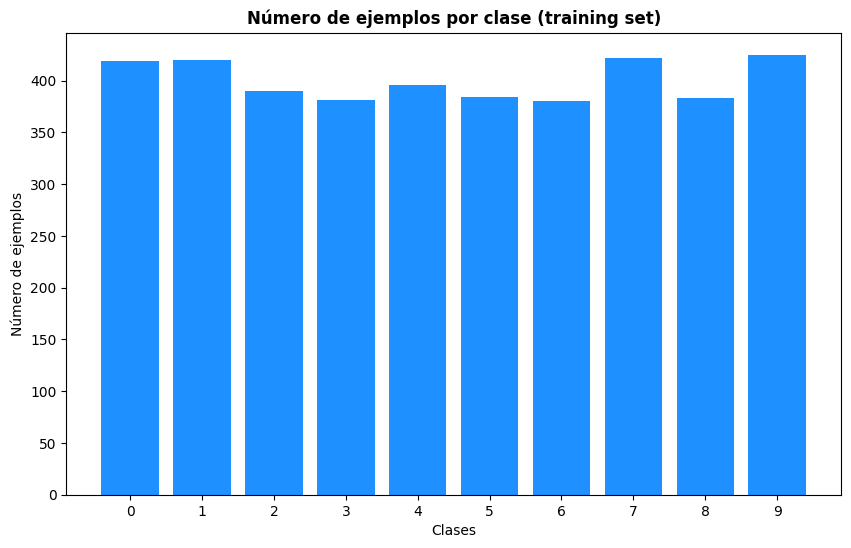

In [ ]:
classes = list(class_counts.keys())
num_examples = list(class_counts.values())

plt.figure(figsize=(10, 6))
plt.bar(classes, num_examples, color = 'dodgerblue')
plt.xlabel('Clases')
plt.ylabel('Número de ejemplos')
plt.title('Número de ejemplos por clase (training set)', fontweight = "bold")
plt.xticks(classes)
plt.show()

In [ ]:
y_train_reduced_original_scalar = np.argmax(y_train_reduced_original, axis=1)

modificaciones = y_train_original != y_train_reduced_original_scalar

indices_modificados = np.where(modificaciones)[0]

print(f"Los índices modificados son: \n {indices_modificados}")

num_modificaciones = len(indices_modificados)
print(f"\nEl número de etiquetas modificadas es: {num_modificaciones}")

percentage = (len(indices_modificados)/len(y_train_original))*100
print(f"\nEl porcentaje de etiquetas modificadas es: {percentage}%")

Los índices modificados son: 
 [   1   22   28   29   34   35   45   67   73   88  108  120  121  161
  164  182  190  203  204  256  268  270  271  285  291  316  317  320
  322  325  329  349  351  354  369  371  378  384  391  405  413  416
  423  424  436  440  451  475  479  483  493  495  516  523  525  526
  528  533  536  546  551  554  570  580  581  587  589  592  594  616
  639  644  664  668  671  694  700  707  713  714  724  733  741  749
  769  775  782  794  796  831  834  847  860  871  886  890  894  898
  904  914  943  952  967 1004 1005 1016 1042 1056 1077 1099 1102 1118
 1128 1129 1160 1165 1180 1183 1194 1195 1196 1208 1210 1215 1217 1246
 1250 1288 1293 1296 1304 1328 1337 1343 1346 1354 1364 1370 1371 1375
 1377 1392 1431 1447 1458 1471 1474 1486 1499 1500 1533 1535 1545 1550
 1554 1556 1560 1568 1569 1573 1584 1591 1592 1634 1641 1643 1656 1657
 1670 1674 1690 1692 1695 1713 1716 1719 1736 1756 1766 1769 1776 1777
 1793 1796 1836 1841 1846 1850 1851 1859 1862 

## Model (2NN)

In [ ]:
from keras.models import Sequential
from keras.layers import  Dense, Input, Flatten

def create_model(size = 1):
  model = Sequential(name = "Model")
  model.add(Input(shape = (28, 28, 1), name = "Input"))
  model.add(Flatten(name = "Flatten"))
  model.add(Dense(units = size, activation='relu', name = "Dense_1"))
  model.add(Dense(units = num_classes, activation='softmax', name = "Dense_2"))

  return model

In [ ]:
model = create_model()
model.summary()

Model: "Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dense_1 (Dense)                      │ (None, 1)                   │             785 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dense_2 (Dense)                      │ (None, 10)                  │              20 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 805 (3.14 KB)

 Trainable params: 805 (3.14 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf

batch_size = 256
num_epochs = 1000

num_units = np.arange(1, 101)

units_array = []
train_loss_array = []
train_accuracy_array = []
test_loss_array = []
test_accuracy_array = []

for units in num_units:
  model = create_model(size = units)

  model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

  print("\n ======> # of units in first dense layer: {} <======\n".format(units))
  hist = model.fit(x_train_reduced, y_train_reduced, batch_size = batch_size, epochs = num_epochs, verbose = 0, validation_data = (x_valid_reduced, y_valid_reduced), shuffle = True)

  train_loss, train_accuracy = model.evaluate(x_train_reduced, y_train_reduced)
  test_loss, test_accuracy = model.evaluate(x_test_reduced, y_test_reduced)

  units_array.append(units)
  train_loss_array.append(train_loss)
  train_accuracy_array.append(train_accuracy)
  test_loss_array.append(test_loss)
  test_accuracy_array.append(test_accuracy)


 ======> # of units in first dense layer: 1 <======

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2993 - loss: 1.7902
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.2891 - loss: 1.8168

 ======> # of units in first dense layer: 2 <======

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5429 - loss: 1.3274
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4933 - loss: 1.4582

 ======> # of units in first dense layer: 3 <======

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7637 - loss: 0.9512
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6760 - loss: 1.0543

 ======> # of units in first dense layer: 4 <======

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8159 - loss: 0.7460
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7246 - loss: 0.9190

 ======> # of units in first dense layer: 5 <======

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8655 - loss: 0.5557
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7492 

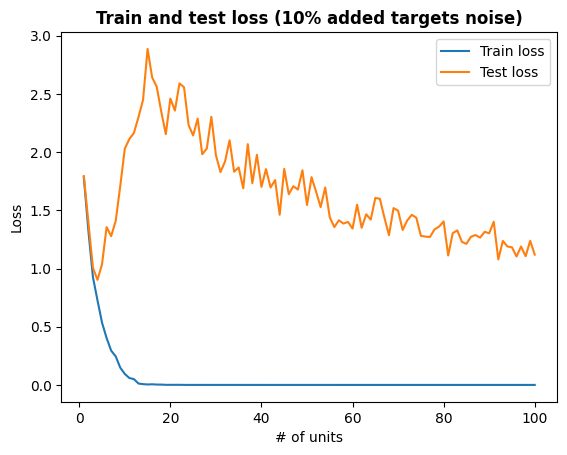

In [ ]:
x = np.arange(0, num_epochs, 1)
plt.title('Train and test loss (10% added targets noise)', fontweight="bold")
plt.xlabel('# of units')
plt.ylabel('Loss')
plt.plot(units_array, train_loss_array, label='Train loss')
plt.plot(units_array, test_loss_array, label='Test loss')
plt.legend()
plt.show()

Finalmente, en este caso observamos como el pico del doble descenso es más "pronunciado" (y desplazado ligeramente hacia la derecha) que en el mismo ejemplo sin ruido agregado a las etiquetas.